In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("mnist.csv")

print(df.shape)
print(df.head())

(10000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      2    0    0    0    0    0    0    0    0    0  ...      0      0   
2      1    0    0    0    0    0    0    0    0    0  ...      0      0   
3      0    0    0    0    0    0    0    0    0    0  ...      0      0   
4      4    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]


In [3]:
print(df["label"].value_counts().sort_index())

label
0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64


In [4]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [5]:
X = df.drop("label", axis=1)
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 784)
y shape: (10000,)


In [6]:
X = X / 255.0

In [7]:
print(X.min().min())
print(X.max().max())

0.0
1.0


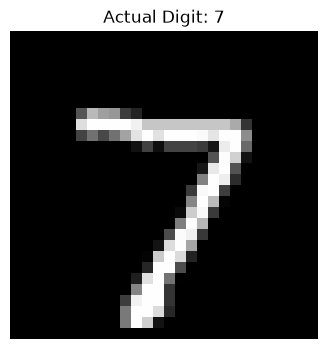

In [8]:
plt.figure(figsize=(4, 4))

plt.imshow(
    X.iloc[0].values.reshape(28, 28),
    cmap="gray"
)

plt.title("Actual Digit: " + str(y.iloc[0]))
plt.axis("off")

plt.show()

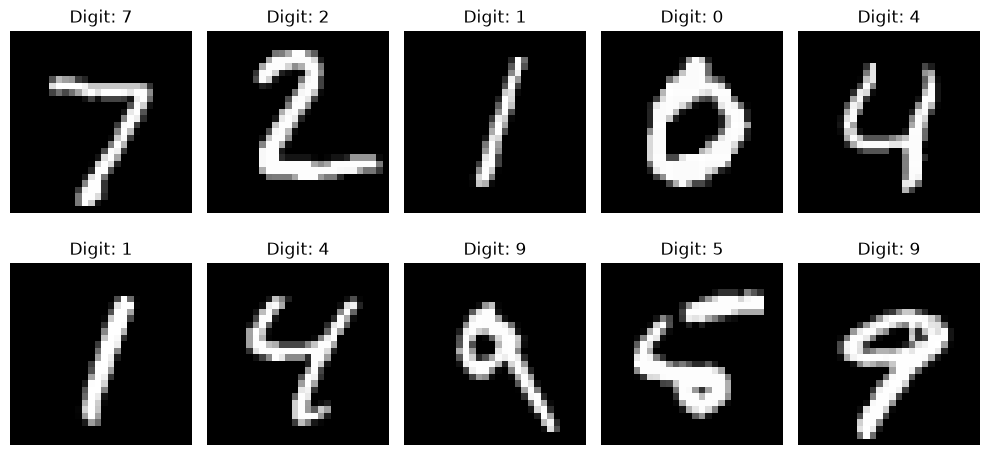

In [9]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X.iloc[i].values.reshape(28, 28),
        cmap="gray"
    )

    plt.title("Digit: " + str(y.iloc[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (8000, 784)
Testing: (2000, 784)


In [11]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [12]:
y_pred = knn.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [13]:
print("Actual:   ", y_test.iloc[:20].values)
print("Predicted:", y_pred[:20])

Actual:    [1 2 4 2 1 0 6 6 6 6 0 8 4 9 8 7 6 8 0 7]
Predicted: [1 2 4 2 1 0 6 6 6 6 0 8 4 9 8 7 6 8 0 7]


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.955
Accuracy Percentage: 95.5 %


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       196
           1       0.94      1.00      0.97       227
           2       0.99      0.91      0.95       206
           3       0.93      0.96      0.94       202
           4       0.95      0.95      0.95       196
           5       0.95      0.94      0.95       178
           6       0.97      0.99      0.98       192
           7       0.92      0.94      0.93       206
           8       0.97      0.93      0.95       195
           9       0.96      0.94      0.95       202

    accuracy                           0.95      2000
   macro avg       0.96      0.95      0.95      2000
weighted avg       0.96      0.95      0.95      2000



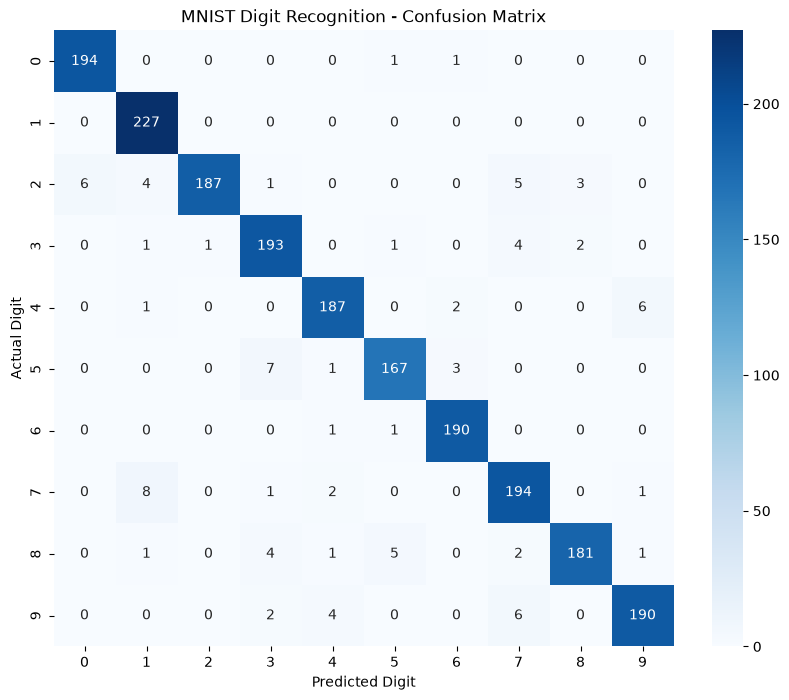

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("MNIST Digit Recognition - Confusion Matrix")

plt.show()

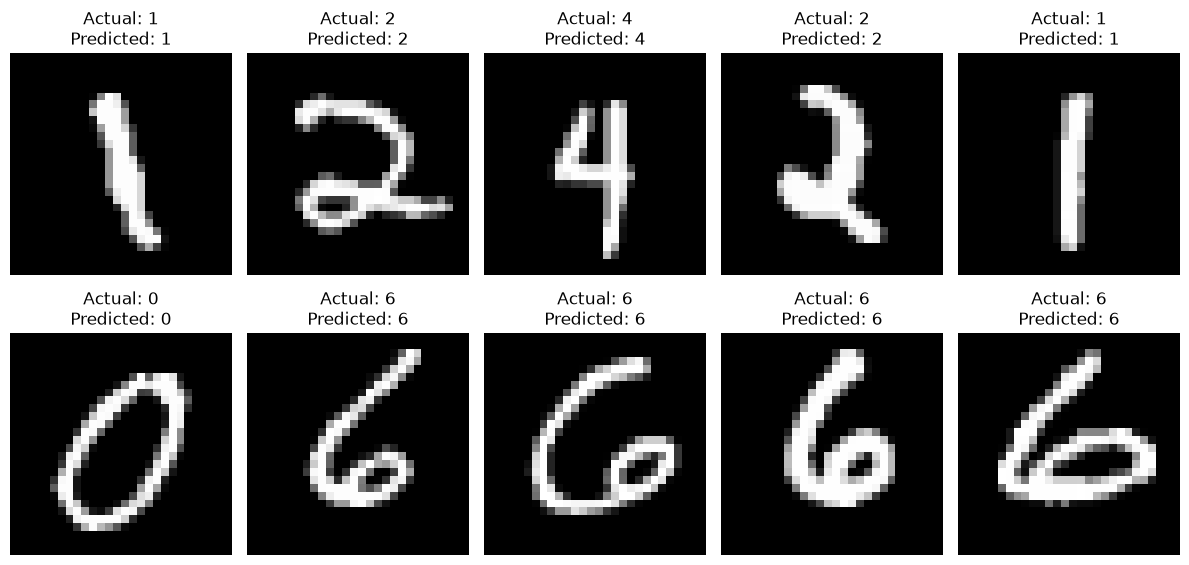

In [17]:
plt.figure(figsize=(12, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    image = X_test.iloc[i].values.reshape(28, 28)

    plt.imshow(image, cmap="gray")

    plt.title(
        "Actual: " + str(y_test.iloc[i]) +
        "\nPredicted: " + str(y_pred[i])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()